# Trabalho Prático 06 - Agentes Inteligentes
## Assistente de Viagens com LangGraph + Groq

**Desenvolvido por:**
  - Gilmar Silva de Medeiros Filho
  - Samuel de Oliveira Vanoni

**GCC128 - Inteligência Artificial - UFLA**

Aplicação multi-agente que ajuda um usuário a se preparar para uma viagem. A colaboração
acontece entre **dois agentes** que trabalham em sequência, compartilhando um estado:

- **Agente Pesquisador** - usa *ferramentas* (`@tool`) para coletar dados reais sobre o
  destino: clima atual, validação de endereço por CEP e cotação de moeda.
- **Agente Planejador** - recebe os dados coletados e produz um roteiro de viagem com
  recomendações (o que levar, dicas de clima, observações de câmbio).

**Ferramentas (`@tool`) usadas - todas APIs públicas e gratuitas, sem chave:**

| Ferramenta | API | O que retorna |
|---|---|---|
| `buscar_clima` | Open-Meteo | Temperatura e condição atual da cidade |
| `consultar_cep` | ViaCEP | Endereço a partir do CEP |
| `cotacao_moeda` | AwesomeAPI | Cotação atual de um par de moedas |

**Framework:** LangGraph &nbsp;•&nbsp; **LLM (gratuito):** Groq (`openai/gpt-oss-120b`)

## 1. Instalação das dependências

Execute uma vez ( ideal no Google Colab ).

In [ ]:
%pip install -q langgraph langchain langchain-groq langchain-core requests

## 2. Configuração da chave da API Groq

A Groq oferece um nível gratuito. É necessário criar uma chave em https://console.groq.com/keys e colar quando
solicitado ( depois de executar a célula abaixo ).
A chave fica apenas em memória ( não é salva no notebook ).

In [1]:
import os
from getpass import getpass

if not os.environ.get("GROQ_API_KEY"):
    os.environ["GROQ_API_KEY"] = getpass("Cole sua GROQ_API_KEY: ")

## 3. Ferramentas (`@tool`)

Cada função decorada com `@tool` vira uma ferramenta que o agente pode decidir chamar.
A *docstring* é o que o LLM lê para entender quando e como usar a ferramenta por isso ela é
escrita de forma descritiva.

In [2]:
import requests
from langchain_core.tools import tool


@tool
def buscar_clima(cidade: str) -> str:
    """Retorna o clima atual (temperatura em graus C e condicao do tempo) de uma cidade.
    Use sempre que precisar saber como esta o tempo no destino da viagem.
    Parametro: cidade (str) - nome da cidade, ex.: 'Florianopolis'."""
    geo = requests.get(
        "https://geocoding-api.open-meteo.com/v1/search",
        params={"name": cidade, "count": 1, "language": "pt"},
        timeout=15,
    ).json()
    if not geo.get("results"):
        return f"Cidade '{cidade}' nao encontrada."
    local = geo["results"][0]
    lat, lon = local["latitude"], local["longitude"]
    prev = requests.get(
        "https://api.open-meteo.com/v1/forecast",
        params={"latitude": lat, "longitude": lon, "current_weather": True},
        timeout=15,
    ).json()["current_weather"]
    codigos = {
        0: "ceu limpo", 1: "predominantemente limpo", 2: "parcialmente nublado",
        3: "nublado", 45: "neblina", 51: "garoa leve", 61: "chuva fraca",
        63: "chuva moderada", 65: "chuva forte", 80: "pancadas de chuva", 95: "trovoada",
    }
    cond = codigos.get(prev["weathercode"], "condicao indefinida")
    nome = f"{local['name']}, {local.get('country', '')}"
    return f"Clima em {nome}: {prev['temperature']} graus C, {cond}, vento {prev['windspeed']} km/h."


@tool
def consultar_cep(cep: str) -> str:
    """Consulta um CEP brasileiro e retorna o endereco (logradouro, bairro, cidade, UF).
    Use para validar ou descobrir o endereco de uma hospedagem informada pelo usuario.
    Parametro: cep (str) - CEP com 8 digitos, ex.: '88010400'."""
    cep_limpo = "".join(filter(str.isdigit, cep))
    dados = requests.get(f"https://viacep.com.br/ws/{cep_limpo}/json/", timeout=15).json()
    if dados.get("erro"):
        return f"CEP {cep} nao encontrado."
    return (f"CEP {dados['cep']}: {dados['logradouro']}, {dados['bairro']}, "
            f"{dados['localidade']}-{dados['uf']}.")


@tool
def cotacao_moeda(par: str) -> str:
    """Retorna a cotacao atual de um par de moedas. Use para informar quanto custa a moeda
    estrangeira em reais. Parametro: par (str) no formato 'USD-BRL', 'EUR-BRL', 'ARS-BRL' etc."""
    par = par.upper().replace("/", "-")
    chave = par.replace("-", "")
    dados = requests.get(f"https://economia.awesomeapi.com.br/last/{par}", timeout=15).json()
    if chave not in dados:
        return f"Par de moedas '{par}' invalido."
    c = dados[chave]
    bid = float(c["bid"])
    casas = 2 if bid >= 1 else 4  # moedas de baixo valor (ex.: ARS) precisam de mais casas
    return f"1 {c['code']} = {bid:.{casas}f} {c['codein']} (cotacao atual)."


ferramentas = [buscar_clima, consultar_cep, cotacao_moeda]

### Teste rápido das ferramentas

Antes de montar os agentes, dá para invocar as ferramentas diretamente para confirmar que as APIs respondem.

In [3]:
print(buscar_clima.invoke("Florianopolis"))
print(consultar_cep.invoke("88010400"))
print(cotacao_moeda.invoke("USD-BRL"))

Clima em Florianópolis, Brasil: 15.4 graus C, parcialmente nublado, vento 4.6 km/h.
CEP 88010-400: Praça Quinze de Novembro, Centro, Florianópolis-SC.
1 USD = 5.19 BRL (cotacao atual).


## 4. LLM (Groq)

In [4]:
from langchain_groq import ChatGroq

# gpt-oss-120b tem tool calling nativo e confiavel no Groq ( o llama-3.3 as vezes erra/inventa o nome da ferramenta no formato de tools do Groq ).
llm = ChatGroq(model="openai/gpt-oss-120b", temperature=0)

## 5. Estado compartilhado e os dois agentes

Os agentes colaboram através de um **estado** compartilhado ( `EstadoViagem` ). O Pesquisador preenche `dados_pesquisa`. O Planejador lê esse campo e preenche `roteiro`.

O **Pesquisador** é um *ReAct agent* criado com `create_agent` ( LangChain v1 ): ele raciocina, decide quais ferramentas chamar, observa os resultados e repete até reunir as informações necessárias.

In [5]:
from typing import TypedDict
from langchain_core.messages import HumanMessage, SystemMessage
from langchain.agents import create_agent


class EstadoViagem(TypedDict):
    pedido: str          # solicitacao do usuario
    dados_pesquisa: str  # preenchido pelo Agente Pesquisador
    roteiro: str         # preenchido pelo Agente Planejador


# --- Agente Pesquisador: usa as ferramentas para coletar dados ---
prompt_pesquisador = (
    "Voce e um agente pesquisador de viagens. Use as ferramentas disponiveis para coletar "
    "dados reais sobre o destino: clima atual (buscar_clima), endereco de hospedagem se houver "
    "um CEP (consultar_cep) e cotacao da moeda local se a viagem for internacional (cotacao_moeda). "
    "Chame as ferramentas necessarias e, ao final, escreva um resumo objetivo dos dados coletados."
)

agente_pesquisador = create_agent(llm, ferramentas, system_prompt=prompt_pesquisador)


def no_pesquisador(estado: EstadoViagem) -> dict:
    resultado = agente_pesquisador.invoke(
        {"messages": [HumanMessage(content=estado["pedido"])]}
    )
    return {"dados_pesquisa": resultado["messages"][-1].content}


# --- Agente Planejador: monta o roteiro a partir dos dados coletados ---
def no_planejador(estado: EstadoViagem) -> dict:
    mensagens = [
        SystemMessage(content=(
            "Voce e um agente planejador de viagens. Com base nos dados de pesquisa fornecidos, "
            "crie um roteiro curto e pratico para o viajante contendo: (1) resumo do clima e o que "
            "levar na mala, (2) dicas para o destino e (3) observacoes de cambio se houver. "
            "Seja claro e organizado em topicos."
        )),
        HumanMessage(content=(
            f"Pedido do usuario: {estado['pedido']}\n\n"
            f"Dados coletados pelo pesquisador:\n{estado['dados_pesquisa']}"
        )),
    ]
    resposta = llm.invoke(mensagens)
    return {"roteiro": resposta.content}

## 6. Montagem do grafo (LangGraph)

Fluxo sequencial: `START -> pesquisador -> planejador -> END`. O grafo orquestra a colaboração
entre os dois agentes.

In [6]:
from langgraph.graph import StateGraph, START, END

construtor = StateGraph(EstadoViagem)
construtor.add_node("pesquisador", no_pesquisador)
construtor.add_node("planejador", no_planejador)

construtor.add_edge(START, "pesquisador")
construtor.add_edge("pesquisador", "planejador")
construtor.add_edge("planejador", END)

grafo = construtor.compile()

### Desenho dos agentes

Diagrama do grafo.

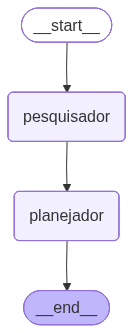

In [7]:
from IPython.display import Image, display

try:
    display(Image(grafo.get_graph().draw_mermaid_png()))
except Exception:
    print(grafo.get_graph().draw_mermaid())

## 7. Execução - demonstração

Dois exemplos prontos mostrando os agentes em ação. No **Exemplo 1** ( destino nacional com CEP ), o Pesquisador aciona `buscar_clima` e `consultar_cep`; em seguida o Planejador monta o roteiro.

In [8]:
from IPython.display import Markdown, display

pedido = (
    "Vou viajar para Florianopolis na proxima semana. Como vai estar o clima e o que devo levar? "
    "Minha pousada fica no CEP 88010-400."
)

resultado = grafo.invoke({"pedido": pedido, "dados_pesquisa": "", "roteiro": ""})

display(Markdown(
    f"## Dados coletados pelo Agente Pesquisador\n\n{resultado['dados_pesquisa']}\n\n"
    f"---\n\n## Roteiro gerado pelo Agente Planejador\n\n{resultado['roteiro']}"
))

## Dados coletados pelo Agente Pesquisador

**Resumo dos dados coletados**

| Item | Informação |
|------|-------------|
| **Clima atual em Florianópolis** | 15,4 °C, parcialmente nublado, vento leve (≈ 4,6 km/h) |
| **Endereço da pousada (CEP 88010‑400)** | Praça Quinze de Novembro, Centro, Florianópolis – SC |

**O que levar**

- **Roupas de meia‑estação**: casaco leve ou jaqueta, suéter ou blusa de manga longa. A temperatura está em torno de 15 °C, podendo cair à noite.
- **Camadas**: camisetas de manga curta + camada extra (blusa ou suéter) para adaptar-se a variações de temperatura ao longo do dia.
- **Proteção contra vento**: um corta‑vento ou jaqueta impermeável, já que há vento moderado.
- **Calçados confortáveis**: tênis ou sapatos fechados para caminhadas urbanas; se pretender ir à praia, leve sandálias, mas esteja preparado para o clima mais fresco.
- **Acessórios**: cachecol leve ou lenço, chapéu ou boné para o sol parcial, óculos de sol.
- **Itens de chuva**: embora não haja previsão de chuva no momento, um guarda‑chuva compacto pode ser útil caso o tempo mude.

Com essas peças você estará preparado para o clima ameno e parcialmente nublado de Florianópolis na próxima semana. Boa viagem!

---

## Roteiro gerado pelo Agente Planejador

**Roteiro rápido para Florianópolis – próxima semana**

---

### 1️⃣ Resumo do clima e o que levar na mala  
- **Clima esperado:**  
  - Temperatura média ≈ 15 °C (pode cair à noite).  
  - Céu parcialmente nublado, vento leve (≈ 4‑5 km/h).  
  - Sem chuva prevista, mas o tempo pode mudar rapidamente.  

- **O que colocar na mala:**  
  - **Camadas:** camisetas de manga curta + suéter ou blusa de manga longa.  
  - **Casaco:** jaqueta leve ou corta‑vento impermeável.  
  - **Acessórios:** cachecol/lenço leve, chapéu ou boné, óculos de sol.  
  - **Calçados:** tênis ou sapato fechado confortável para passeios urbanos; sandálias ou chinelo caso vá à praia.  
  - **Itens extras:** guarda‑chuva compacto (por precaução) e protetor solar (mesmo com céu nublado).  

---

### 2️⃣ Dicas para o destino (próximo à sua pousada – Praça Quinze de Novembro, Centro)  
- **Explorar a pé:** o centro histórico é compacto; visite a Praça XV, a Catedral Metropolitana e o Mercado Público.  
- **Praias próximas:** a 15‑20 min de carro/ônibus estão a Praia da Joaquina e a Praia Mole – leve a jaqueta, pois o mar está frio.  
- **Gastronomia:** experimente frutos do mar frescos no Mercado Público e a tradicional sequência de camarão em restaurantes do centro.  
- **Transporte:** o sistema de ônibus da cidade cobre bem o centro; aplicativos de carro são abundantes e úteis para praias mais distantes.  
- **Segurança:** áreas turísticas são seguras, mas mantenha objetos de valor guardados em bolsos internos ou na bolsa da pousada.  
- **Atividades ao ar livre:** trilhas curtas como a da Lagoinha do Leste podem ser feitas mesmo com clima ameno – use calçado fechado e leve água.  

---

### 3️⃣ Observações de câmbio  
- **Moeda local:** Real (BRL).  
- **Câmbio:** Em Florianópolis a cotação costuma ser próxima à taxa oficial (aprox. 1 USD ≈ 5,30 BRL em junho/2026).  
- **Onde trocar:** casas de câmbio no Shopping Beiramar, no centro da cidade e em bancos. Cartões de crédito/débito são amplamente aceitos; avise seu banco sobre a viagem para evitar bloqueios.  

---

**Boa viagem!** Aproveite o clima fresco, a cultura local e as belas paisagens de Florianópolis. 🌊🏖️🧥

No **Exemplo 2** trocamos para um destino internacional. Como a viagem é fora do país, o Pesquisador passa a acionar também a ferramenta `cotacao_moeda` — sem nenhuma mudança no código.

In [9]:
# Exemplo 2 — destino internacional (aciona cotacao_moeda)
pedido2 = "Quero passar uma semana em Buenos Aires. Como esta o clima e a cotacao do peso argentino (ARS-BRL)?"
r2 = grafo.invoke({"pedido": pedido2, "dados_pesquisa": "", "roteiro": ""})

display(Markdown(r2["roteiro"]))

**Viagem de 1 semana a Buenos Aires – Guia rápido**

---

### 1️⃣ Resumo do clima & o que levar na mala  
- **Clima atual:** 7 °C, céu limpo, vento de 13,6 km/h – temperatura típica de inverno (junho).  
- **Previsão geral:** dias frios a amenos, possibilidade de chuvas leves à tarde.  

**O que colocar na bagagem:**  
| Tipo | Itens recomendados |
|------|--------------------|
| **Roupas** | Casaco pesado ou jaqueta corta‑vento, suéteres de lã, blusas de manga longa, calças jeans ou de sarja, cachecol, luvas e gorro. |
| **Camadas** | Camisetas térmicas ou de manga curta para usar por baixo. |
| **Calçados** | Bota ou sapato fechado confortável (ideal para caminhar nas ruas de paralelepípedos). |
| **Acessórios** | Óculos de sol (sol forte mesmo no frio), protetor solar, guarda‑chuva compacto ou capa de chuva. |
| **Outros** | Adaptador de tomada (tipo C/I), carregador portátil, medicamentos de uso contínuo, máscara facial (se preferir). |

---

### 2️⃣ Dicas para o destino  

| Tema | Sugestões práticas |
|------|-------------------|
| **Transporte** | - Cartão SUBE: carregue crédito e use em ônibus, metrô e trens. <br> - Uber e Cabify são abundantes e seguros. |
| **Alimentação** | - Experimente o **asado**, **empanadas** e o famoso **choripán**. <br> - Visite um café tradicional em Palermo para provar o **café con leche**. |
| **Passeios imperdíveis** | - **Plaza de Mayo** e Casa Rosada. <br> - **San Telmo** (feira de antiguidades aos domingos). <br> - **La Boca** e o estádio La Bombonera. <br> - **Jardim Botânico** e **Bosques de Palermo** para caminhadas. |
| **Cultura** | - Show de tango em uma milonga autêntica (ex.: Café Tortoni ou El Querandí). <br> - Visite museus como MALBA (arte moderna) e o Museu Nacional de Belas Artes. |
| **Segurança** | - Evite exibir objetos de valor nas áreas turísticas movimentadas. <br> - Use caixas de correio ou cofres de hotéis para documentos importantes. |
| **Horários** | - Muitos restaurantes fecham entre 15 h e 19 h; planeje um lanche leve (café, sorvete) nesse intervalo. |
| **Internet** | - Wi‑Fi gratuito em cafés, bibliotecas e alguns parques; considere comprar um chip pré‑pago da operadora local (Claro, Movistar) para dados ilimitados. |

---

### 3️⃣ Observações de câmbio  

- **Cotação atual:** 1 ARS = **0,0035 BRL** (ou seja, 1 BRL ≈ 285 ARS).  
- **Como trocar:** <br>• Casas de câmbio oficiais no centro (Avenida Corrientes, Puerto Madero) oferecem as melhores taxas. <br>• Caixas eletrônicos (ATMs) costumam aplicar a taxa do banco + 2‑3 % de IOF; verifique se seu cartão aceita saque internacional sem tarifa extra.  
- **Dica de economia:** Leve parte do orçamento em **reais** e troque pequenas quantias à medida que precisar, evitando carregar muito dinheiro em espécie.  
- **Aplicativos úteis:** XE, OANDA ou o app do Banco do Brasil para acompanhar a variação diária da ARS/BRL.  

---

**Resumo rápido:**  
- **Clima frio (≈7 °C)** → vista-se em camadas, leve casaco quente e calçados fechados.  
- **Explore a cidade a pé ou de SUBE**, aproveite a gastronomia local e os shows de tango.  
- **Câmbio favorável**: 1 BRL ≈ 285 ARS; troque em casas de câmbio oficiais ou use ATM com atenção às tarifas.  

Boa viagem e aproveite tudo que Buenos Aires tem a oferecer! 🌎✈️🍷

## 8. Conclusões

- A aplicação demonstra **colaboração entre dois agentes** orquestrados pelo LangGraph: o
  **Pesquisador** coleta dados do mundo real e o **Planejador** os transforma em um roteiro útil,
  comunicando-se por um **estado compartilhado**.
- O uso de **ferramentas (`@tool`)** mostra o padrão *ReAct*: o agente raciocina, decide qual
  ferramenta chamar, observa o resultado e itera — em vez de "alucinar" dados, ele consulta
  fontes reais (Open-Meteo, ViaCEP, AwesomeAPI).
- A separação de responsabilidades (quem pesquisa ≠ quem planeja) deixa o sistema mais modular:
  cada agente tem um *prompt* e um conjunto de capacidades próprios, e novos agentes/ferramentas
  podem ser adicionados ao grafo sem reescrever os existentes.
- O LangGraph com estado tipado (`TypedDict`) torna o fluxo explícito e fácil de visualizar,
  o que ajuda no entendimento e na depuração de sistemas multi-agente.


## 9. Experimente você mesmo

Edite a variável `meu_pedido` na célula abaixo com o **destino** e a **pergunta** que quiser e execute.
Para acionar todas as ferramentas, inclua um **CEP** e/ou um **par de moedas** ( ex.: `USD-BRL` ).

In [10]:
from IPython.display import Markdown, display

# >>> ESCREVA SEU PEDIDO AQUI <<<
# Inclua o destino e o que quiser saber. Dicas:
#  - informe um CEP para acionar a ferramenta de endereco;
#  - cite um par de moedas (ex.: USD-BRL, EUR-BRL) para acionar a cotacao.
meu_pedido = "Vou passar o próximo fim de semana em Caxambu-MG. Como está o clima por lá e quais são os pontos mais legais pra visitar?"

estado_final = grafo.invoke({"pedido": meu_pedido, "dados_pesquisa": "", "roteiro": ""})

display(Markdown(
    f"## Dados coletados pelo Agente Pesquisador\n\n{estado_final['dados_pesquisa']}\n\n"
    f"---\n\n## Roteiro gerado pelo Agente Planejador\n\n{estado_final['roteiro']}"
))

## Dados coletados pelo Agente Pesquisador

**Clima em Caxambu (MG) – próximo fim de semana**  
- **Temperatura atual:** 20,7 °C  
- **Condição:** Predominantemente limpo (céu claro)  
- **Vento:** 4 km/h  

**Principais atrações para visitar em Caxambu**

| Atrativo | Tipo | Destaques / O que fazer |
|----------|------|--------------------------|
| **Parque das Águas** | Parque natural | Fonte de água mineral com propriedades terapêuticas; trilhas leves, áreas de piquenique e lagos. |
| **Cachoeira do Salto** | Natureza | Queda d’água de ~30 m, ideal para banho e fotos; acesso por trilha curta e bem sinalizada. |
| **Museu da Água** | Cultural | Exposição sobre a história das águas minerais da região e a cultura local. |
| **Praça da Estação** | Centro histórico | Arquitetura colonial, cafés e lojinhas de artesanato; ponto de partida para caminhar pelo centro. |
| **Rota das Águas (Circuito Turístico)** | Roteiro | Percurso que inclui as fontes de água mineral, o Parque das Águas e o Mirante da Serra da Mantiqueira, com vistas panorâmicas. |
| **Mirante da Serra da Mantiqueira** | Vista | Vista panorâmica da serra e da cidade; ideal ao pôr‑do‑sol. |
| **Termas de Caxambu** | Bem‑estar | Complexo de águas termais com piscinas, sauna e tratamentos de hidroterapia. |
| **Trilha da Pedra do Baú (próxima a Caxambu)** | Aventura | Para quem gosta de trekking mais desafiador; vista espetacular do topo. |

**Dicas rápidas**

- **Roupas:** Leve um agasalho leve; as manhãs e noites podem ficar mais frescas na serra.  
- **Hidratação:** Aproveite as fontes de água mineral para se hidratar e experimentar as diferentes propriedades.  
- **Transporte:** O centro da cidade é bem caminhável; para atrações fora do centro (cachoeira, mirante) use carro ou táxi local.  
- **Gastronomia:** Experimente o “pão de queijo” mineiro e pratos à base de truta, muito comum na região.

Aproveite o clima agradável e as belezas naturais de Caxambu! Boa viagem!

---

## Roteiro gerado pelo Agente Planejador

**Fim de semana em Caxambu – MG**  
*(2 noites / 3 dias – 23 a 25/06)*  

---

## 1️⃣ Resumo do clima & o que levar na mala  

| Item | Detalhe |
|------|---------|
| **Clima esperado** | Céu predominantemente limpo, temperatura média **20 °C**. Manhãs e noites podem ficar entre **15‑17 °C**; dias mais quentes chegam a **22‑23 °C**. Vento leve (≈ 4 km/h). |
| **O que levar** | • Camisetas de manga curta e uma ou duas de manga longa <br>• Agasalho leve ou jaqueta corta‑vento (para manhãs/noites) <br>• Calça confortável + bermuda <br>• Tênis ou sapatilha para trilhas leves <br>• Chinelo e roupa de banho (para as termas) <br>• Chapéu/boné e protetor solar <br>• Garrafa reutilizável (para repor nas fontes de água mineral) <br>• Capa de chuva fina (caso haja mudança rápida) |

---

## 2️⃣ Dicas práticas para aproveitar Caxambu  

### 📅 Roteiro sugerido (flexível)

| Horário | Atividade | Local |
|---------|-----------|-------|
| **Dia 1 – Sábado** | Chegada e check‑in | Hotel/Pousada no centro |
| 09:00 – 11:30 | Passeio pelo **Parque das Águas** – trilhas leves, lago e fontes | Parque das Águas |
| 12:00 – 13:30 | Almoço típico (truta grelhada + pão de queijo) | Restaurante na Praça da Estação |
| 14:00 – 15:30 | Visita ao **Museu da Água** | Museu da Água |
| 16:00 – 18:00 | Caminhada e café na **Praça da Estação** (lojinhas de artesanato) | Praça da Estação |
| 19:00 – 20:30 | Jantar e relaxar nas **Termas de Caxambu** (piscinas termais) | Termas de Caxambu |
| **Dia 2 – Domingo** | 08:00 – 09:30 | Café da manhã e saída para a **Cachoeira do Salto** (trilha curta, foto) | Cachoeira do Salto |
| 10:00 – 12:00 | **Rota das Águas** – visita às fontes e ao **Mirante da Serra da Mantiqueira** (pôr‑do‑sol) | Rota das Águas / Mirante |
| 12:30 – 14:00 | Almoço em restaurante local (prato de truta ou feijoada) | Centro |
| 15:00 – 18:00 | Opcional: **Trilha da Pedra do Baú** (para quem gosta de trekking mais exigente) – saída de carro até o ponto de partida | Próximo a Caxambu |
| 19:00 | Jantar livre (sugestão: fondue de queijo) | Centro |
| **Dia 3 – Segunda** | 08:00 – 09:30 | Café da manhã tranquilo | Hotel |
| 10:00 – 12:00 | Último passeio livre: compras de artesanato ou visita rápida a alguma fonte que ainda não viu | Centro |
| 12:30 | Check‑out e retorno |  |

### ✔️ Dicas rápidas  

* **Água mineral:** Experimente as diferentes fontes (bica, gás, baixa). Elas são gratuitas nos pontos turísticos.  
* **Transporte:** O centro é totalmente caminhável. Para a cachoeira, mirante e Pedra do Baú, o carro (ou táxi) é mais prático.  
* **Gastronomia:** Não perca o **pão de queijo** artesanal, a **truta ao molho de ervas** e o **café colonial** nas cafeterias da Praça da Estação.  
* **Segurança:** Leve só o necessário nas trilhas; use protetor solar e repelente.  
* **Internet:** Wi‑Fi gratuito em cafés e na maioria das pousadas; sinal de celular costuma ser bom na cidade, mas pode cair nas áreas de serra.  

---

## 3️⃣ Observações de câmbio  

* **Moeda:** Real (R$). Caxambu não possui casas de câmbio; a maioria dos estabelecimentos aceita apenas pagamento em dinheiro ou cartão.  
* **Dica:** Se precisar de dinheiro em espécie, retire no caixa eletrônico (ATM) da cidade ou faça a troca em bancos de cidades próximas (São José dos Campos, Pouso Alegre).  
* **Cartões:** Visa, Mastercard e Elo são amplamente aceitos; avise seu banco sobre a viagem para evitar bloqueios.  

---

**Bom fim de semana!** Aproveite o clima ameno, as águas minerais e as paisagens da Serra da Mantiqueira. 🌄🧭